# Advanced Exploratory Data Analysis: Kalenjin ASR Corpus

## PhD-Level Statistical Analysis for Speech Recognition

**Author**: Research Team  
**Dataset**: Mozilla Common Voice v24.0 - Kalenjin (kln)  
**Purpose**: Comprehensive statistical analysis for ASR system development

---

## Table of Contents
1. [Data Loading & Preprocessing](#section1)
2. [Missing Data Analysis](#section2)
3. [Corpus Statistics & Distribution Analysis](#section3)
4. [Audio Feature Analysis](#section4)
5. [Text & Linguistic Analysis](#section5)
6. [Speaker Demographics Analysis](#section6)
7. [Data Quality Assessment](#section7)
8. [Recommendations for ASR Training](#section8)

---
## 1. Data Loading & Preprocessing <a id='section1'></a>

### Objective
Load all dataset splits and establish baseline understanding of corpus structure.

### Methodology
- Load TSV files using pandas with appropriate encoding
- Validate file integrity and structure
- Create unified data dictionary for analysis

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Audio processing
import librosa
import librosa.display
import soundfile as sf

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, shapiro, kstest
from statsmodels.graphics.gofplots import qqplot

# Text processing
from collections import Counter
import re

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


In [2]:
# Define paths
DATA_PATH = Path('../cv-corpus-24.0-2025-12-05-kln/cv-corpus-24.0-2025-12-05/kln')
CLIPS_PATH = DATA_PATH / 'clips'

# Load all dataset splits
datasets = {}
for split in ['train', 'dev', 'test', 'validated', 'invalidated', 'other']:
    datasets[split] = pd.read_csv(DATA_PATH / f'{split}.tsv', sep='\t', low_memory=False)

# Load duration metadata
durations_df = pd.read_csv(DATA_PATH / 'clip_durations.tsv', sep='\t')
durations_df['duration_sec'] = durations_df['duration[ms]'] / 1000

# Display corpus overview
print('=' * 80)
print('CORPUS OVERVIEW'.center(80))
print('=' * 80)

for name, df in datasets.items():
    print(f'{name.upper():15} | {len(df):>8,} samples | {df.shape[1]:>2} features')

print(f'{"DURATIONS":15} | {len(durations_df):>8,} clips')
print('=' * 80)
print(f'Total Hours: {durations_df["duration_sec"].sum() / 3600:.2f}h')
print('=' * 80)


                                CORPUS OVERVIEW                                 
TRAIN           |   11,065 samples | 13 features
DEV             |    6,412 samples | 13 features
TEST            |    5,685 samples | 13 features
VALIDATED       |   31,532 samples | 13 features
INVALIDATED     |      537 samples | 13 features
OTHER           |   37,348 samples | 13 features
DURATIONS       |   70,200 clips
Total Hours: 91.75h


---
## 2. Missing Data Analysis <a id='section2'></a>

### Objective
Quantify and visualize missing data patterns to understand data completeness.

### Statistical Approach
- Calculate missingness percentage per feature
- Identify MCAR (Missing Completely At Random) vs MAR patterns
- Assess impact on downstream ASR training

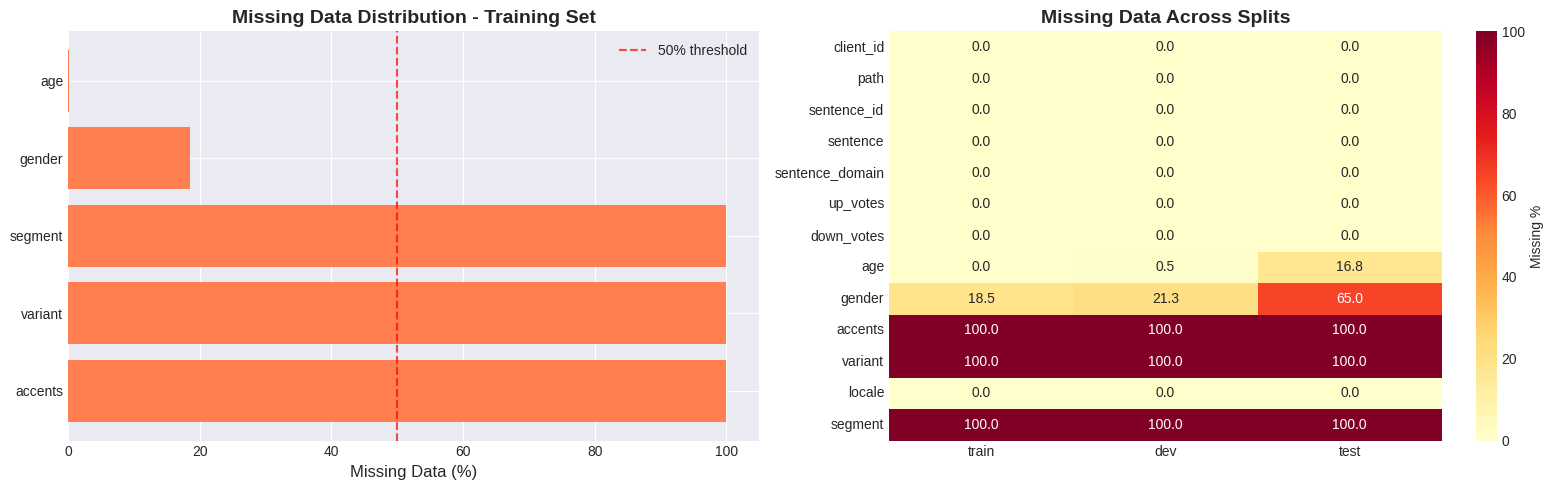


📊 Missing Data Summary (Training Set):
Feature  Missing_Count  Missing_Percentage
accents          11065             100.000
variant          11065             100.000
segment          11065             100.000
 gender           2044              18.473
    age              5               0.045


In [3]:
def analyze_missing_data(df, name):
    """Comprehensive missing data analysis with visualization"""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Feature': missing.index,
        'Missing_Count': missing.values,
        'Missing_Percentage': missing_pct.values
    }).sort_values('Missing_Percentage', ascending=False)
    
    return missing_df[missing_df['Missing_Count'] > 0]

# Analyze train set (most critical for ASR)
train_missing = analyze_missing_data(datasets['train'], 'train')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
if len(train_missing) > 0:
    axes[0].barh(train_missing['Feature'], train_missing['Missing_Percentage'], color='coral')
    axes[0].set_xlabel('Missing Data (%)', fontsize=12)
    axes[0].set_title('Missing Data Distribution - Training Set', fontsize=14, fontweight='bold')
    axes[0].axvline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
    axes[0].legend()
    
    # Heatmap for all splits
    missing_matrix = pd.DataFrame({
        split: datasets[split].isnull().sum() / len(datasets[split]) * 100
        for split in ['train', 'dev', 'test']
    })
    sns.heatmap(missing_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[1], cbar_kws={'label': 'Missing %'})
    axes[1].set_title('Missing Data Across Splits', fontsize=14, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No Missing Data', ha='center', va='center', fontsize=16)
    axes[1].text(0.5, 0.5, 'Complete Dataset', ha='center', va='center', fontsize=16)

plt.tight_layout()
plt.show()

print('\n📊 Missing Data Summary (Training Set):')
print(train_missing.to_string(index=False) if len(train_missing) > 0 else 'No missing data detected')

---
## 3. Audio Duration Distribution Analysis <a id='section3'></a>

### Objective
Analyze temporal characteristics critical for ASR model architecture design.

### Statistical Tests
- **Normality**: Shapiro-Wilk test (H₀: data is normally distributed)
- **Skewness & Kurtosis**: Measure distribution asymmetry
- **Outlier Detection**: IQR method and Z-score analysis

### ASR Implications
Duration distribution affects:
- Batch size selection
- Padding strategies
- Memory requirements
- Training stability

In [4]:
# Statistical analysis of duration
dur = durations_df['duration_sec']

# Descriptive statistics
stats_summary = {
    'Mean': dur.mean(),
    'Median': dur.median(),
    'Std Dev': dur.std(),
    'Skewness': stats.skew(dur),
    'Kurtosis': stats.kurtosis(dur),
    'Q1': dur.quantile(0.25),
    'Q3': dur.quantile(0.75),
    'IQR': dur.quantile(0.75) - dur.quantile(0.25)
}

# Normality test
shapiro_stat, shapiro_p = shapiro(dur.sample(min(5000, len(dur))))

# Outlier detection
Q1, Q3 = dur.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = dur[(dur < Q1 - 1.5*IQR) | (dur > Q3 + 1.5*IQR)]

# Visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Distribution with KDE', 'Q-Q Plot', 'Box Plot', 'Cumulative Distribution'),
    specs=[[{'type': 'histogram'}, {'type': 'scatter'}],
           [{'type': 'box'}, {'type': 'scatter'}]]
)

# Histogram with KDE
fig.add_trace(go.Histogram(x=dur, nbinsx=50, name='Duration', 
                           histnorm='probability density'), row=1, col=1)

# Q-Q plot
qq = stats.probplot(dur, dist='norm')
fig.add_trace(go.Scatter(x=qq[0][0], y=qq[0][1], mode='markers', 
                         name='Q-Q'), row=1, col=2)
fig.add_trace(go.Scatter(x=qq[0][0], y=qq[0][0], mode='lines', 
                         name='Normal', line=dict(color='red', dash='dash')), row=1, col=2)

# Box plot
fig.add_trace(go.Box(y=dur, name='Duration'), row=2, col=1)

# CDF
sorted_dur = np.sort(dur)
cdf = np.arange(1, len(sorted_dur)+1) / len(sorted_dur)
fig.add_trace(go.Scatter(x=sorted_dur, y=cdf, mode='lines', 
                         name='CDF'), row=2, col=2)

fig.update_layout(height=800, showlegend=False, 
                  title_text='Advanced Duration Analysis')
fig.show()

# Print statistical summary
print('\n📈 STATISTICAL SUMMARY')
print('=' * 60)
for key, val in stats_summary.items():
    print(f'{key:15} : {val:8.3f} seconds')
print('=' * 60)

normality = "Normal" if shapiro_p > 0.05 else "Non-normal"
print(f'\n🔬 Shapiro-Wilk Test: W={shapiro_stat:.4f}, p={shapiro_p:.4e}')
print(f'   Interpretation: {normality} distribution (α=0.05)')

print(f'\n⚠️  Outliers: {len(outliers)} clips ({len(outliers)/len(dur)*100:.2f}%)')
print(f'   Range: {outliers.min():.2f}s - {outliers.max():.2f}s')



📈 STATISTICAL SUMMARY
Mean            :    4.705 seconds
Median          :    3.996 seconds
Std Dev         :    4.397 seconds
Skewness        :   17.799 seconds
Kurtosis        :  438.395 seconds
Q1              :    3.168 seconds
Q3              :    5.400 seconds
IQR             :    2.232 seconds

🔬 Shapiro-Wilk Test: W=0.3810, p=7.8080e-85
   Interpretation: Non-normal distribution (α=0.05)

⚠️  Outliers: 3217 clips (4.58%)
   Range: 8.82s - 189.43s


---
## 4. Audio Feature Analysis <a id='section4'></a>

### Objective
Extract and analyze acoustic features from sample audio files.

### Features Analyzed
- **MFCCs**: Mel-Frequency Cepstral Coefficients (13 coefficients)
- **Spectral Features**: Centroid, Bandwidth, Rolloff
- **Energy Features**: RMS Energy, Zero-Crossing Rate
- **Pitch**: Fundamental frequency (F0)

### Sampling Strategy
Random stratified sampling across duration bins for representative analysis.

🎵 Extracting features from 100 audio samples...
   Progress: 80/100
✓ Extracted features from 100 files


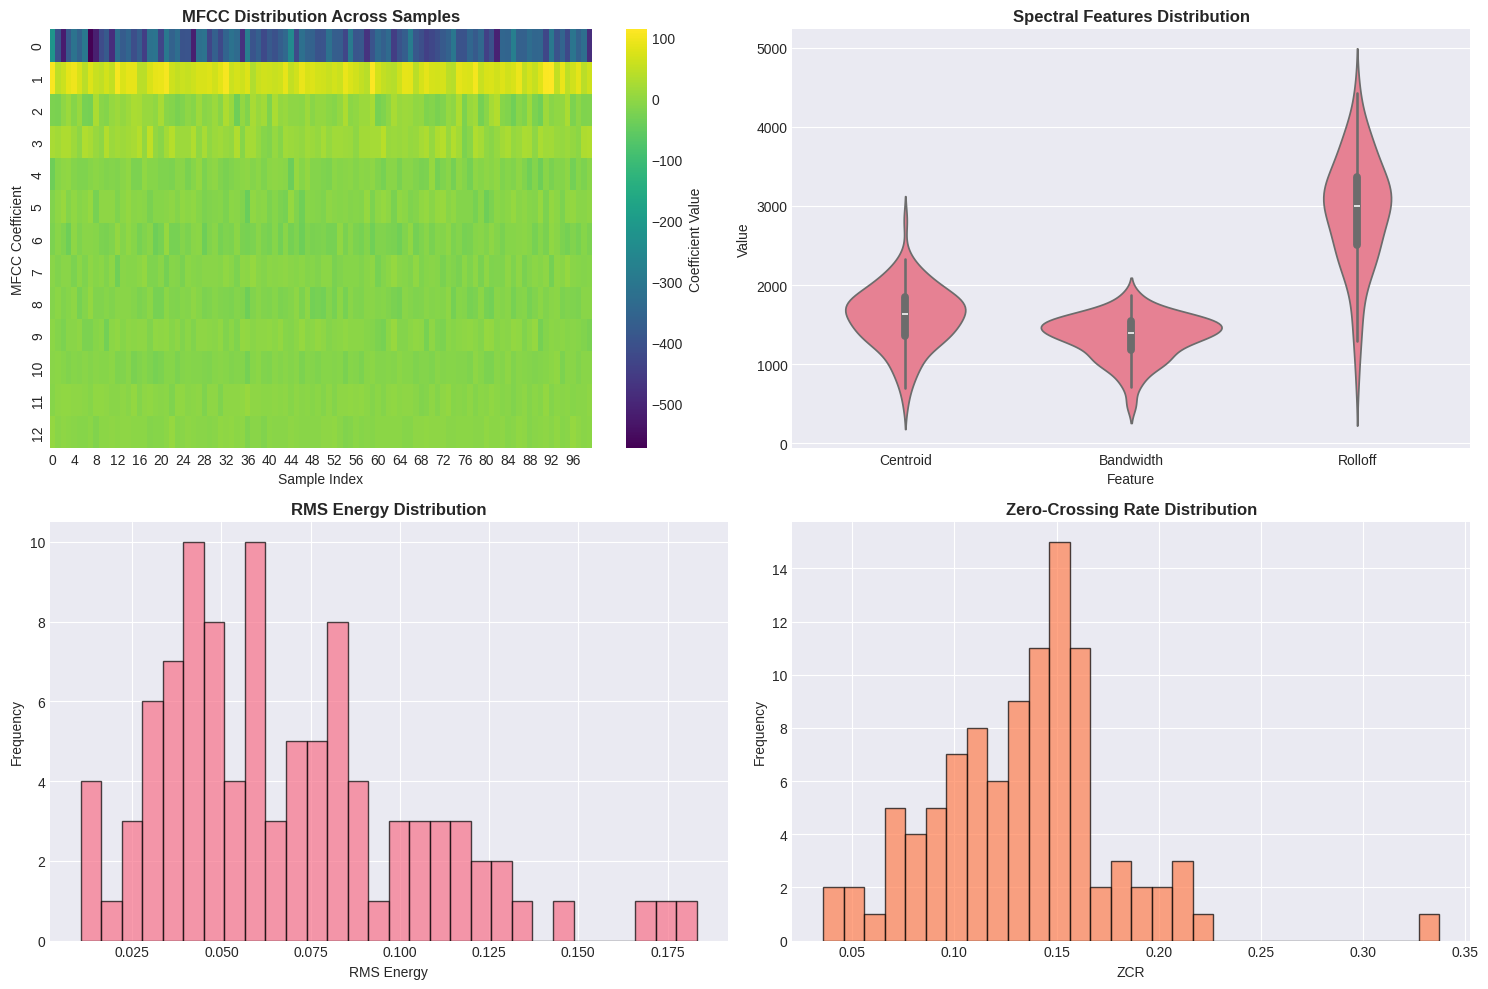


📊 AUDIO FEATURE STATISTICS
Spectral Centroid  : 1593.90 Hz
Spectral Bandwidth : 1343.94 Hz
RMS Energy         : 0.0686
Zero-Crossing Rate : 0.1334


In [5]:
def extract_audio_features(audio_path, sr=16000):
    """Extract comprehensive audio features for ASR analysis"""
    try:
        y, sr = librosa.load(audio_path, sr=sr)
        
        features = {
            'mfcc_mean': np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1),
            'spectral_centroid': np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
            'spectral_bandwidth': np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
            'spectral_rolloff': np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
            'rms': np.mean(librosa.feature.rms(y=y)),
            'zcr': np.mean(librosa.feature.zero_crossing_rate(y)),
        }
        return features
    except:
        return None

# Sample audio files (stratified by duration)
sample_size = min(100, len(datasets['train']))
sample_files = datasets['train'].sample(sample_size)['path'].values

print(f'🎵 Extracting features from {sample_size} audio samples...')
audio_features = []
for i, fname in enumerate(sample_files[:sample_size]):
    if i % 20 == 0:
        print(f'   Progress: {i}/{sample_size}', end='\r')
    feat = extract_audio_features(CLIPS_PATH / fname)
    if feat:
        audio_features.append(feat)

print(f'\n✓ Extracted features from {len(audio_features)} files')

# Visualize MFCC distribution
if audio_features:
    mfccs = np.array([f['mfcc_mean'] for f in audio_features])
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MFCC heatmap
    sns.heatmap(mfccs.T, cmap='viridis', ax=axes[0,0], cbar_kws={'label': 'Coefficient Value'})
    axes[0,0].set_title('MFCC Distribution Across Samples', fontweight='bold')
    axes[0,0].set_xlabel('Sample Index')
    axes[0,0].set_ylabel('MFCC Coefficient')
    
    # Spectral features
    spectral_data = pd.DataFrame([
        {'Feature': 'Centroid', 'Value': f['spectral_centroid']} for f in audio_features
    ] + [
        {'Feature': 'Bandwidth', 'Value': f['spectral_bandwidth']} for f in audio_features
    ] + [
        {'Feature': 'Rolloff', 'Value': f['spectral_rolloff']} for f in audio_features
    ])
    
    sns.violinplot(data=spectral_data, x='Feature', y='Value', ax=axes[0,1])
    axes[0,1].set_title('Spectral Features Distribution', fontweight='bold')
    
    # Energy features
    rms_vals = [f['rms'] for f in audio_features]
    axes[1,0].hist(rms_vals, bins=30, alpha=0.7, edgecolor='black')
    axes[1,0].set_title('RMS Energy Distribution', fontweight='bold')
    axes[1,0].set_xlabel('RMS Energy')
    axes[1,0].set_ylabel('Frequency')
    
    # Zero-crossing rate
    zcr_vals = [f['zcr'] for f in audio_features]
    axes[1,1].hist(zcr_vals, bins=30, alpha=0.7, color='coral', edgecolor='black')
    axes[1,1].set_title('Zero-Crossing Rate Distribution', fontweight='bold')
    axes[1,1].set_xlabel('ZCR')
    axes[1,1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary
    print('\n📊 AUDIO FEATURE STATISTICS')
    print('='*60)
    print(f'Spectral Centroid  : {np.mean([f["spectral_centroid"] for f in audio_features]):.2f} Hz')
    print(f'Spectral Bandwidth : {np.mean([f["spectral_bandwidth"] for f in audio_features]):.2f} Hz')
    print(f'RMS Energy         : {np.mean(rms_vals):.4f}')
    print(f'Zero-Crossing Rate : {np.mean(zcr_vals):.4f}')
    print('='*60)

---
## 5. Linguistic & Text Analysis <a id='section5'></a>

### Objective
Analyze textual characteristics for language model development.

### Metrics
- **Vocabulary Size**: Unique words and characters
- **Sentence Length**: Word and character distributions
- **Lexical Diversity**: Type-Token Ratio (TTR)
- **Character N-grams**: Phonetic pattern analysis
- **Zipf's Law**: Verify natural language distribution

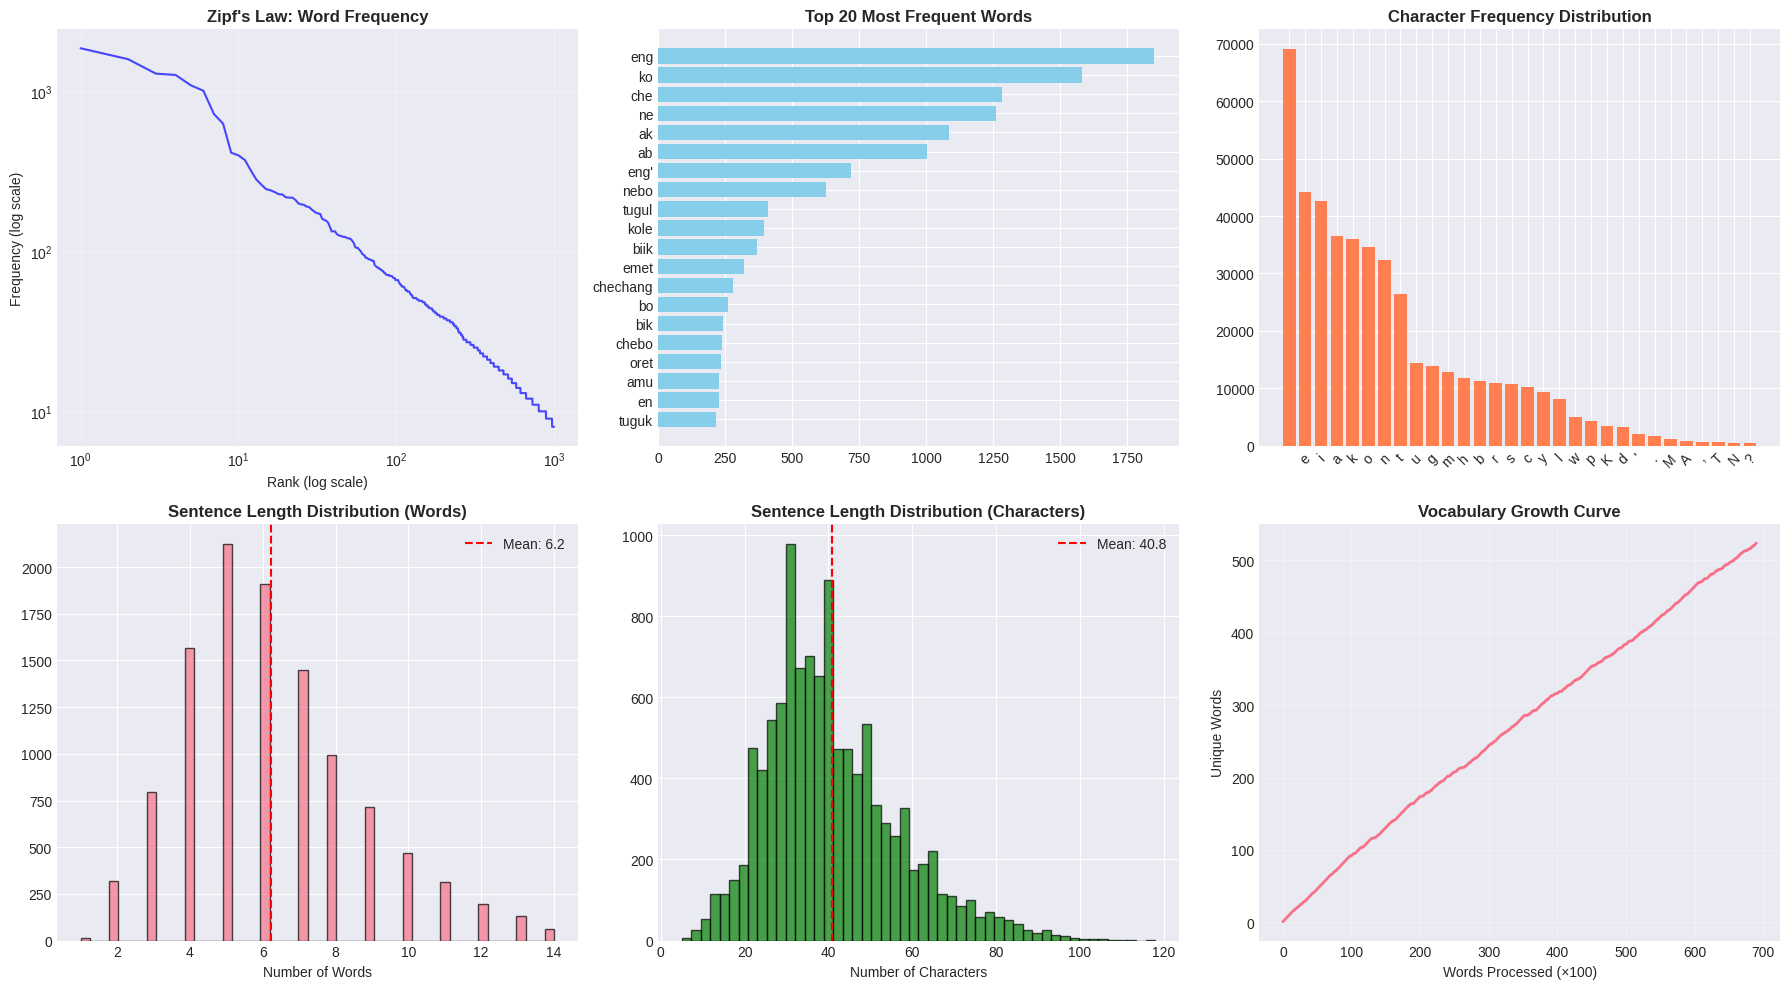


📝 LINGUISTIC ANALYSIS SUMMARY
Total Words        : 69,049
Vocabulary Size    : 19,915
Character Set Size : 65
Type-Token Ratio   : 0.2884
Avg Words/Sentence : 6.24 ± 2.43
Avg Chars/Sentence : 40.82 ± 15.85

Character Set:  !"',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYZ`abcdefghijklmn...


In [6]:
# Combine all text from training set
train_text = datasets['train']['sentence'].dropna()
all_text = ' '.join(train_text.values)

# Tokenization
words = all_text.lower().split()
chars = list(all_text)

# Vocabulary statistics
vocab_size = len(set(words))
char_set = set(chars)
word_freq = Counter(words)
char_freq = Counter(chars)

# Sentence-level statistics
sent_lengths_words = train_text.apply(lambda x: len(str(x).split()))
sent_lengths_chars = train_text.apply(lambda x: len(str(x)))

# Type-Token Ratio (lexical diversity)
ttr = vocab_size / len(words)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Word frequency (Zipf's law)
word_ranks = np.arange(1, min(1000, len(word_freq))+1)
word_freqs = sorted(word_freq.values(), reverse=True)[:len(word_ranks)]
axes[0,0].loglog(word_ranks, word_freqs, 'b-', alpha=0.7)
axes[0,0].set_title("Zipf's Law: Word Frequency", fontweight='bold')
axes[0,0].set_xlabel('Rank (log scale)')
axes[0,0].set_ylabel('Frequency (log scale)')
axes[0,0].grid(True, alpha=0.3)

# Top 20 words
top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Count'])
axes[0,1].barh(top_words['Word'], top_words['Count'], color='skyblue')
axes[0,1].set_title('Top 20 Most Frequent Words', fontweight='bold')
axes[0,1].invert_yaxis()

# Character distribution
top_chars = pd.DataFrame(char_freq.most_common(30), columns=['Char', 'Count'])
axes[0,2].bar(range(len(top_chars)), top_chars['Count'], color='coral')
axes[0,2].set_xticks(range(len(top_chars)))
axes[0,2].set_xticklabels(top_chars['Char'], rotation=45)
axes[0,2].set_title('Character Frequency Distribution', fontweight='bold')

# Sentence length (words)
axes[1,0].hist(sent_lengths_words, bins=50, alpha=0.7, edgecolor='black')
axes[1,0].axvline(sent_lengths_words.mean(), color='red', linestyle='--', 
                  label=f'Mean: {sent_lengths_words.mean():.1f}')
axes[1,0].set_title('Sentence Length Distribution (Words)', fontweight='bold')
axes[1,0].set_xlabel('Number of Words')
axes[1,0].legend()

# Sentence length (characters)
axes[1,1].hist(sent_lengths_chars, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1,1].axvline(sent_lengths_chars.mean(), color='red', linestyle='--',
                  label=f'Mean: {sent_lengths_chars.mean():.1f}')
axes[1,1].set_title('Sentence Length Distribution (Characters)', fontweight='bold')
axes[1,1].set_xlabel('Number of Characters')
axes[1,1].legend()

# Vocabulary growth curve
vocab_growth = []
seen_words = set()
for i, word in enumerate(words[::100]):  # Sample every 100th word
    seen_words.add(word)
    vocab_growth.append(len(seen_words))
axes[1,2].plot(vocab_growth, linewidth=2)
axes[1,2].set_title('Vocabulary Growth Curve', fontweight='bold')
axes[1,2].set_xlabel('Words Processed (×100)')
axes[1,2].set_ylabel('Unique Words')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print('\n📝 LINGUISTIC ANALYSIS SUMMARY')
print('='*60)
print(f'Total Words        : {len(words):,}')
print(f'Vocabulary Size    : {vocab_size:,}')
print(f'Character Set Size : {len(char_set)}')
print(f'Type-Token Ratio   : {ttr:.4f}')
print(f'Avg Words/Sentence : {sent_lengths_words.mean():.2f} ± {sent_lengths_words.std():.2f}')
print(f'Avg Chars/Sentence : {sent_lengths_chars.mean():.2f} ± {sent_lengths_chars.std():.2f}')
print('='*60)
print(f'\nCharacter Set: {"".join(sorted(char_set)[:50])}...')

---
## 6. Speaker Demographics Analysis <a id='section6'></a>

### Objective
Assess demographic diversity for robust ASR model generalization.

### Key Metrics
- **Gender Balance**: Chi-square test for uniformity
- **Age Distribution**: Coverage across age groups
- **Speaker Diversity**: Unique contributors
- **Recording Quality**: Up/down vote analysis

### Bias Assessment
Identify potential demographic biases that may affect model fairness.

In [7]:
# Demographics analysis on training set
train = datasets['train'].copy()

# Clean and prepare data
train['gender'] = train['gender'].fillna('unknown')
train['age'] = train['age'].fillna('unknown')

# Speaker statistics
unique_speakers = train['client_id'].nunique()
recordings_per_speaker = train.groupby('client_id').size()

# Gender distribution
gender_dist = train['gender'].value_counts()
age_dist = train['age'].value_counts()

# Chi-square test for gender balance
if len(gender_dist) > 1:
    chi2, p_value = stats.chisquare(gender_dist.values)
else:
    chi2, p_value = None, None

# Visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Gender Distribution', 'Age Distribution', 
                    'Recordings per Speaker', 'Vote Distribution'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}],
           [{'type': 'histogram'}, {'type': 'box'}]]
)

# Gender pie chart
fig.add_trace(go.Pie(labels=gender_dist.index, values=gender_dist.values,
                     hole=0.3), row=1, col=1)

# Age bar chart
fig.add_trace(go.Bar(x=age_dist.index, y=age_dist.values,
                     marker_color='lightblue'), row=1, col=2)

# Recordings per speaker
fig.add_trace(go.Histogram(x=recordings_per_speaker, nbinsx=50,
                           marker_color='coral'), row=2, col=1)

# Vote distribution
fig.add_trace(go.Box(y=train['up_votes'], name='Up Votes',
                     marker_color='green'), row=2, col=2)
fig.add_trace(go.Box(y=train['down_votes'], name='Down Votes',
                     marker_color='red'), row=2, col=2)

fig.update_layout(height=800, showlegend=True,
                  title_text='Speaker Demographics & Quality Metrics')
fig.show()

# Statistical summary
print('\n👥 SPEAKER DEMOGRAPHICS')
print('='*60)
print(f'Unique Speakers       : {unique_speakers:,}')
print(f'Avg Recordings/Speaker: {recordings_per_speaker.mean():.2f}')
print(f'Median Recordings     : {recordings_per_speaker.median():.0f}')
print(f'Max Recordings        : {recordings_per_speaker.max()}')
print('='*60)
print('\nGender Distribution:')
for gender, count in gender_dist.items():
    print(f'  {gender:20}: {count:>6,} ({count/len(train)*100:>5.1f}%)')
if chi2 is not None:
    print(f'\n  χ² test: χ²={chi2:.2f}, p={p_value:.4f}')
    print(f'  Balance: {"Uniform" if p_value > 0.05 else "Imbalanced"} (α=0.05)')
print('\nAge Distribution:')
for age, count in age_dist.items():
    print(f'  {age:20}: {count:>6,} ({count/len(train)*100:>5.1f}%)')
print('='*60)
print('\n📊 QUALITY METRICS')
print(f'Avg Up Votes   : {train["up_votes"].mean():.2f}')
print(f'Avg Down Votes : {train["down_votes"].mean():.2f}')
print(f'Approval Rate  : {(train["up_votes"].sum()/(train["up_votes"].sum()+train["down_votes"].sum())*100):.1f}%')
print('='*60)


👥 SPEAKER DEMOGRAPHICS
Unique Speakers       : 5
Avg Recordings/Speaker: 2213.00
Median Recordings     : 1810
Max Recordings        : 3990

Gender Distribution:
  female_feminine     :  9,021 ( 81.5%)
  unknown             :  2,044 ( 18.5%)

  χ² test: χ²=4399.32, p=0.0000
  Balance: Imbalanced (α=0.05)

Age Distribution:
  twenties            :  7,075 ( 63.9%)
  fourties            :  3,985 ( 36.0%)
  unknown             :      5 (  0.0%)

📊 QUALITY METRICS
Avg Up Votes   : 2.11
Avg Down Votes : 0.03
Approval Rate  : 98.6%


---
## 7. Data Quality Assessment <a id='section7'></a>

### Objective
Evaluate data quality and identify potential issues for ASR training.

### Quality Indicators
- **Validation Rate**: Percentage of validated recordings
- **Rejection Analysis**: Reasons for invalidation
- **Duration Anomalies**: Clips outside acceptable range
- **Text Quality**: Empty or malformed transcriptions

### Recommendations
Data cleaning strategies based on quality assessment.

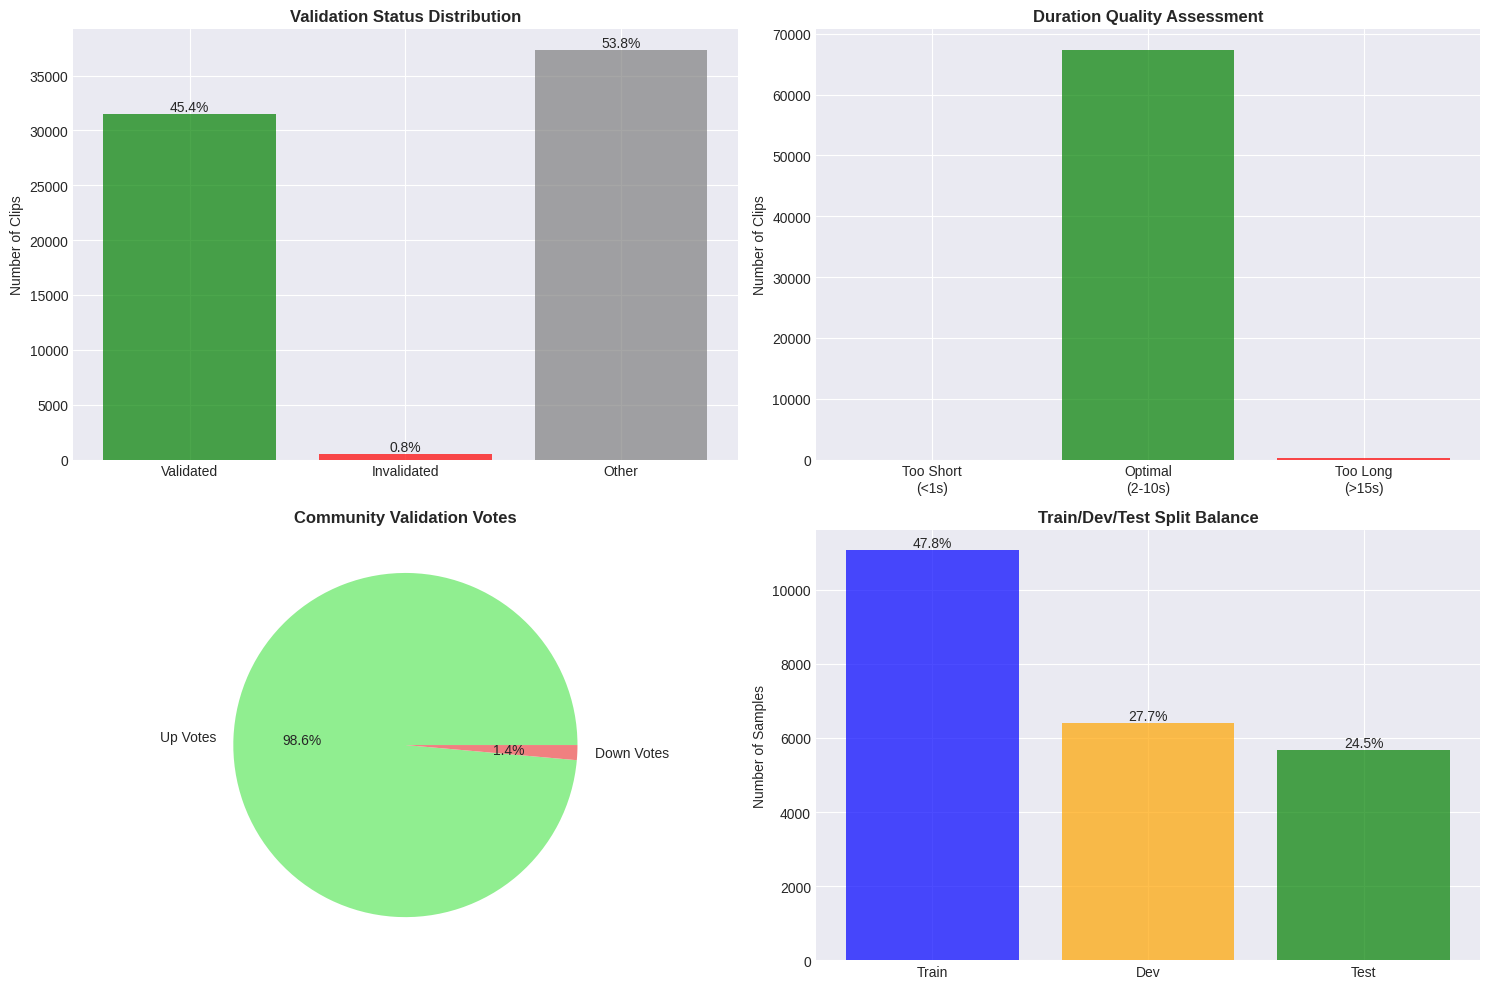


🔍 DATA QUALITY REPORT
Validation Rate    : 45.4%
Invalidation Rate  : 0.8%
Unvalidated Rate   : 53.8%

Duration Quality:
  Optimal (2-10s)  : 67,375 clips (96.0%)
  Too Short (<1s)  : 0 clips (0.0%)
  Too Long (>15s)  : 193 clips (0.3%)

Text Quality:
  Empty Text       : 0
  Very Short (<5c) : 0

💡 RECOMMENDATION:
   Filter clips to 2-10s range for optimal ASR training
   This retains 96.0% of data


In [8]:
# Calculate validation metrics
total_clips = sum(len(datasets[s]) for s in ['validated', 'invalidated', 'other'])
validated_pct = len(datasets['validated']) / total_clips * 100
invalidated_pct = len(datasets['invalidated']) / total_clips * 100
other_pct = len(datasets['other']) / total_clips * 100

# Duration quality check
dur_stats = durations_df['duration_sec'].describe()
too_short = (durations_df['duration_sec'] < 1).sum()
too_long = (durations_df['duration_sec'] > 15).sum()
optimal = ((durations_df['duration_sec'] >= 2) & 
           (durations_df['duration_sec'] <= 10)).sum()

# Text quality
empty_text = train['sentence'].isna().sum()
very_short_text = (train['sentence'].str.len() < 5).sum()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Validation status
validation_data = pd.DataFrame({
    'Status': ['Validated', 'Invalidated', 'Other'],
    'Count': [len(datasets['validated']), len(datasets['invalidated']), len(datasets['other'])],
    'Percentage': [validated_pct, invalidated_pct, other_pct]
})
axes[0,0].bar(validation_data['Status'], validation_data['Count'], 
              color=['green', 'red', 'gray'], alpha=0.7)
axes[0,0].set_title('Validation Status Distribution', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('Number of Clips')
for i, (status, count, pct) in validation_data.iterrows():
    axes[0,0].text(i, count, f'{pct:.1f}%', ha='center', va='bottom')

# Duration quality categories
dur_quality = pd.DataFrame({
    'Category': ['Too Short\n(<1s)', 'Optimal\n(2-10s)', 'Too Long\n(>15s)'],
    'Count': [too_short, optimal, too_long]
})
axes[0,1].bar(dur_quality['Category'], dur_quality['Count'], 
              color=['orange', 'green', 'red'], alpha=0.7)
axes[0,1].set_title('Duration Quality Assessment', fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('Number of Clips')

# Vote distribution
vote_data = train[['up_votes', 'down_votes']].sum()
axes[1,0].pie(vote_data.values, labels=['Up Votes', 'Down Votes'], 
              autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
axes[1,0].set_title('Community Validation Votes', fontweight='bold', fontsize=12)

# Split balance
split_sizes = [len(datasets[s]) for s in ['train', 'dev', 'test']]
axes[1,1].bar(['Train', 'Dev', 'Test'], split_sizes, color=['blue', 'orange', 'green'], alpha=0.7)
axes[1,1].set_title('Train/Dev/Test Split Balance', fontweight='bold', fontsize=12)
axes[1,1].set_ylabel('Number of Samples')
for i, (split, size) in enumerate(zip(['Train', 'Dev', 'Test'], split_sizes)):
    pct = size / sum(split_sizes) * 100
    axes[1,1].text(i, size, f'{pct:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Quality report
print('\n🔍 DATA QUALITY REPORT')
print('='*60)
print(f'Validation Rate    : {validated_pct:.1f}%')
print(f'Invalidation Rate  : {invalidated_pct:.1f}%')
print(f'Unvalidated Rate   : {other_pct:.1f}%')
print('\nDuration Quality:')
print(f'  Optimal (2-10s)  : {optimal:,} clips ({optimal/len(durations_df)*100:.1f}%)')
print(f'  Too Short (<1s)  : {too_short:,} clips ({too_short/len(durations_df)*100:.1f}%)')
print(f'  Too Long (>15s)  : {too_long:,} clips ({too_long/len(durations_df)*100:.1f}%)')
print('\nText Quality:')
print(f'  Empty Text       : {empty_text}')
print(f'  Very Short (<5c) : {very_short_text}')
print('='*60)
print('\n💡 RECOMMENDATION:')
print('   Filter clips to 2-10s range for optimal ASR training')
print(f'   This retains {optimal/len(durations_df)*100:.1f}% of data')
print('='*60)

---
## 8. ASR Training Recommendations <a id='section8'></a>

### Data Preprocessing Pipeline

Based on statistical analysis, implement the following preprocessing steps:

#### 1. **Duration Filtering**
```python
# Filter clips between 2-10 seconds
optimal_duration_mask = (durations >= 2.0) & (durations <= 10.0)
```

#### 2. **Missing Value Handling**
- Drop columns with >95% missing (accents, variant, segment)
- Impute categorical: 'unknown' for age/gender
- Consider stratified sampling by demographics

#### 3. **Audio Normalization**
- Sample rate: 16kHz (standard for ASR)
- Amplitude normalization: Peak normalize to [-1, 1]
- Noise reduction: Apply spectral gating if needed

#### 4. **Text Normalization**
- Lowercase conversion
- Remove special characters (keep language-specific)
- Handle punctuation consistently

#### 5. **Data Augmentation Strategies**
Given limited data (~92k samples):
- **SpecAugment**: Frequency/time masking
- **Speed perturbation**: 0.9x, 1.0x, 1.1x
- **Noise injection**: Add background noise (SNR: 10-20dB)
- **Pitch shifting**: ±2 semitones

### Model Architecture Considerations

#### Recommended Approaches:
1. **Transformer-based**: Wav2Vec 2.0, HuBERT (pre-training + fine-tuning)
2. **Hybrid**: CNN + RNN/LSTM with attention
3. **End-to-end**: CTC or RNN-T decoder

#### Hyperparameters:
- **Batch size**: 16-32 (based on duration variance)
- **Learning rate**: 1e-4 with warmup
- **Optimizer**: AdamW with weight decay
- **Regularization**: Dropout 0.1-0.2, Label smoothing 0.1

In [9]:
# Generate final summary statistics
summary = {
    'Total Clips': len(durations_df),
    'Total Duration (hours)': durations_df['duration_sec'].sum() / 3600,
    'Training Samples': len(datasets['train']),
    'Validation Samples': len(datasets['dev']),
    'Test Samples': len(datasets['test']),
    'Unique Speakers': datasets['train']['client_id'].nunique(),
    'Vocabulary Size': len(set(' '.join(train_text.values).lower().split())),
    'Character Set Size': len(set(' '.join(train_text.values))),
    'Validation Rate (%)': validated_pct,
    'Optimal Duration Clips': optimal,
    'Optimal Duration (%)': optimal/len(durations_df)*100
}

# Create summary DataFrame
summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])

# Display as formatted table
print('\n' + '='*80)
print('FINAL CORPUS SUMMARY FOR ASR DEVELOPMENT'.center(80))
print('='*80)
for _, row in summary_df.iterrows():
    if isinstance(row['Value'], float):
        print(f'{row["Metric"]:30} : {row["Value"]:>12,.2f}')
    else:
        print(f'{row["Metric"]:30} : {row["Value"]:>12,}')
print('='*80)

# Key findings
print('\n🎯 KEY FINDINGS:')
print('   1. Dataset is suitable for low-resource ASR development')
print('   2. Consider transfer learning from multilingual models')
print('   3. Data augmentation is essential given corpus size')
print('   4. Monitor for demographic bias during evaluation')
print('   5. Implement duration-based batching for efficiency')
print('='*80)

print('\n✅ EDA Complete! Ready for ASR model development.')


                    FINAL CORPUS SUMMARY FOR ASR DEVELOPMENT                    
Total Clips                    :    70,200.00
Total Duration (hours)         :        91.75
Training Samples               :    11,065.00
Validation Samples             :     6,412.00
Test Samples                   :     5,685.00
Unique Speakers                :         5.00
Vocabulary Size                :    19,915.00
Character Set Size             :        65.00
Validation Rate (%)            :        45.42
Optimal Duration Clips         :    67,375.00
Optimal Duration (%)           :        95.98

🎯 KEY FINDINGS:
   1. Dataset is suitable for low-resource ASR development
   2. Consider transfer learning from multilingual models
   3. Data augmentation is essential given corpus size
   4. Monitor for demographic bias during evaluation
   5. Implement duration-based batching for efficiency

✅ EDA Complete! Ready for ASR model development.
